In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import re
#need conda install xlrd

# -----------------------------
# 1. LOAD DATA
# -----------------------------
file_path = "lng-exports.xls"  # update if needed

df = pd.read_excel(file_path, engine="xlrd")

mpl.rcParams['svg.fonttype'] = 'none'

# Preview
print(df.head())
print(df.columns)


        Date  U.S. Natural Gas Exports (MMcf)  \
0 1973-06-30                            77169   
1 1974-06-30                            76789   
2 1975-06-30                            72675   
3 1976-06-30                            64710   
4 1977-06-30                            55625   

   U.S. Natural Gas Pipeline Exports (MMcf)  \
0                                       NaN   
1                                       NaN   
2                                       NaN   
3                                       NaN   
4                                       NaN   

   U.S. Natural Gas Pipeline Exports to Canada (MMcf)  \
0                                              14823    
1                                              13263    
2                                              10219    
3                                               7506    
4                                                 31    

   U.S. Natural Gas Pipeline Exports to Mexico (MMcf)  \
0                     

In [66]:
def clean_col(col):
    col = str(col).strip()
    col = re.sub(r"\s+", " ", col)   # collapse repeated spaces
    return col

df.columns = [clean_col(c) for c in df.columns]

print("Original columns:")
for c in df.columns[:10]:
    print(c)

Original columns:
Date
U.S. Natural Gas Exports (MMcf)
U.S. Natural Gas Pipeline Exports (MMcf)
U.S. Natural Gas Pipeline Exports to Canada (MMcf)
U.S. Natural Gas Pipeline Exports to Mexico (MMcf)
Liquefied U.S. Natural Gas Exports (MMcf)
Liquefied U.S. Natural Gas Exports by Vessel and Truck (MMcf)
Liquefied U.S. Natural Gas Exports by Vessel (MMcf)
U.S. Liquefied Natural Gas Exports by Vessel to Antigua and Barbuda (Million Cubic Feet)
Liquefied U.S. Natural Gas Exports by Vessel to Argentina (Million Cubic Feet)


In [67]:
# -----------------------------------
# 3. COLUMN MAP FOR MAP 1
# -----------------------------------
column_map = {
    "U.S. Natural Gas Exports (MMcf)": "total_ng_mmcf",
    "U.S. Natural Gas Pipeline Exports (MMcf)": "pipeline_total_mmcf",
    "U.S. Natural Gas Pipeline Exports to Canada (MMcf)": "pipeline_canada_mmcf",
    "U.S. Natural Gas Pipeline Exports to Mexico (MMcf)": "pipeline_mexico_mmcf",
    "Liquefied U.S. Natural Gas Exports (MMcf)": "lng_total_mmcf",
    "Liquefied U.S. Natural Gas Exports by Vessel and Truck (MMcf)": "lng_vessel_truck_mmcf",
    "Liquefied U.S. Natural Gas Exports by Vessel (MMcf)": "lng_vessel_mmcf",
}

# keep only columns that exist in the file
existing_map = {k: v for k, v in column_map.items() if k in df.columns}

# find a year column
year_candidates = [c for c in df.columns if "date" in c.lower()]
if not year_candidates:
    raise ValueError("Could not find a Year column. Inspect df.columns and set it manually.")
year_col = year_candidates[0]

# clean df
plot_df = df[[year_col] + list(existing_map.keys())].rename(
    columns={year_col: "date", **existing_map}
)

In [68]:
plot_df

,date,total_ng_mmcf,pipeline_total_mmcf,pipeline_canada_mmcf,pipeline_mexico_mmcf,lng_total_mmcf,lng_vessel_truck_mmcf,lng_vessel_mmcf
0,1973-06-30,77169,NaN,14823,13999,NaN,NaN,NaN
1,1974-06-30,76789,NaN,13263,13268,NaN,NaN,NaN
2,1975-06-30,72675,NaN,10219,9453,NaN,NaN,NaN
3,1976-06-30,64710,NaN,7506,7425,NaN,NaN,NaN
4,1977-06-30,55625,NaN,31,3940,NaN,NaN,NaN
5,1978-06-30,52532,NaN,66,4033,NaN,NaN,NaN
6,1979-06-30,55673,NaN,76,4308,NaN,NaN,NaN
7,1980-06-30,48731,NaN,113,3886,NaN,NaN,NaN
8,1981-06-30,59372,NaN,106,3337,NaN,NaN,NaN
9,1982-06-30,51728,NaN,162,1705,NaN,NaN,NaN


In [69]:
# keep date
plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")

# convert value columns only
value_cols = [c for c in plot_df.columns if c != "date"]
for col in value_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# convert to Bcf = 1 Bcf = 1000 Mmcf
plot_df["total_ng_bcf"] = plot_df["total_ng_mmcf"] / 1000
plot_df["pipeline_total_bcf"] = plot_df["pipeline_total_mmcf"] / 1000
plot_df["lng_vessel_bcf"] = plot_df["lng_vessel_mmcf"] / 1000

# sort by date
plot_df = plot_df.sort_values("date")

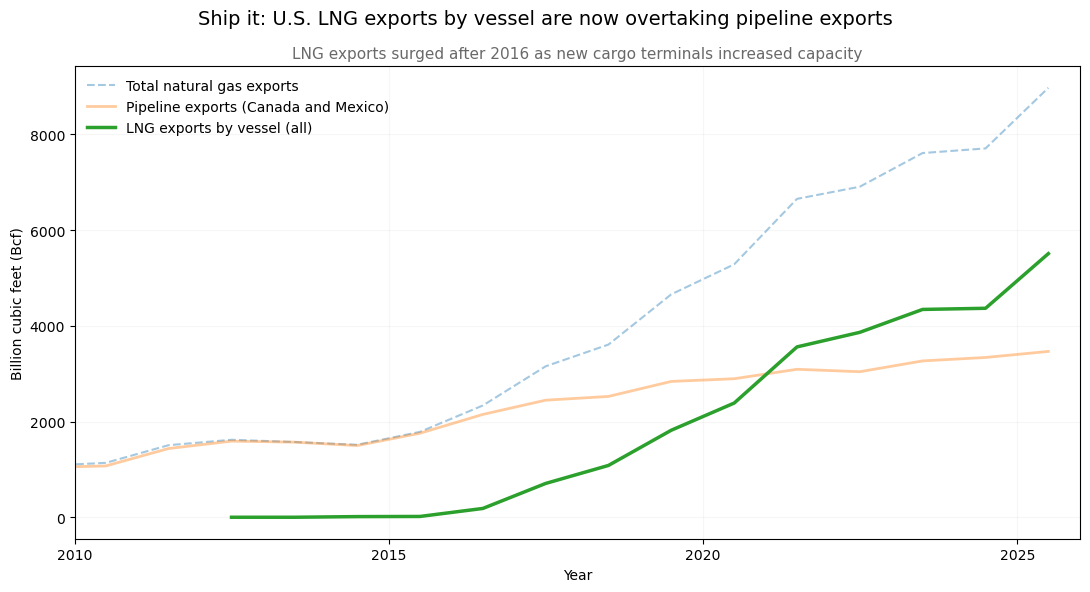

In [70]:
# PLOT1: How have U.S. natural gas exports shifter over time? A macro view.
plt.figure(figsize=(11, 6))
plt.plot(plot_df["date"], plot_df["total_ng_bcf"], alpha=0.4, linewidth=1.5, linestyle="--", label="Total natural gas exports")
plt.plot(plot_df["date"], plot_df["pipeline_total_bcf"], alpha=0.4, linewidth=2, label="Pipeline exports (Canada and Mexico)")
plt.plot(plot_df["date"], plot_df["lng_vessel_bcf"], linewidth=2.5, label="LNG exports by vessel (all)")
plt.suptitle("Ship it: U.S. LNG exports by vessel are now overtaking pipeline exports", fontsize=14)
plt.title("LNG exports surged after 2016 as new cargo terminals increased capacity", fontsize=11, color="dimgray")
plt.xlabel("Year")
plt.ylabel("Billion cubic feet (Bcf)")
plt.grid(True, alpha=0.1)
plt.legend(frameon=False)
plt.xlim(pd.to_datetime("2010-01-01"), pd.to_datetime("2025-12-31"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()



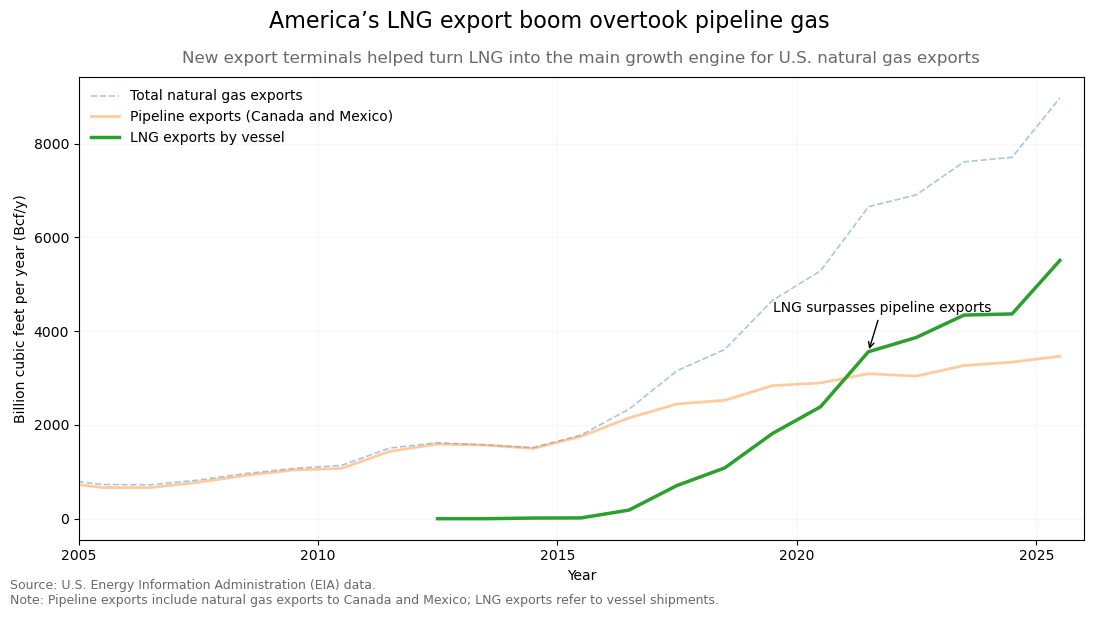

In [ ]:
plot_2 = plot_df[plot_df["date"] >= "2000-01-01"].copy()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    plot_2["date"],
    plot_2["total_ng_bcf"],
    alpha=0.4,
    linewidth=1.2,
    linestyle="--",
    label="Total natural gas exports"
)

ax.plot(
    plot_2["date"],
    plot_2["pipeline_total_bcf"],
    alpha=0.4,
    linewidth=2,
    label="Pipeline exports (Canada and Mexico)"
)

ax.plot(
    plot_2["date"],
    plot_2["lng_vessel_bcf"],
    linewidth=2.5,
    label="LNG exports by vessel"
)

# crossing 
valid = plot_2.dropna(
    subset=["lng_vessel_bcf", "pipeline_total_bcf"]
).sort_values("date")

cross = valid[
    valid["lng_vessel_bcf"] > valid["pipeline_total_bcf"]
]

if not cross.empty:
    c = cross.iloc[0]

    ax.annotate(
        "LNG surpasses pipeline exports",
        xy=(c["date"], c["lng_vessel_bcf"]),
        xytext=(
            c["date"] - pd.DateOffset(years=2),
            c["lng_vessel_bcf"] + 850
        ),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

# headline
plt.suptitle(
    "America’s LNG export boom overtook pipeline gas",
    fontsize=16,
)

# dek
ax.set_title(
    "New export terminals helped turn LNG into the main growth engine for U.S. natural gas exports",
    fontsize=12,
    color="dimgray",
    pad=10
)

ax.set_xlabel("Year")
ax.set_ylabel("Billion cubic feet per year (Bcf/y)")

ax.grid(True, alpha=0.1)
ax.legend(frameon=False)

ax.set_xlim(
    pd.to_datetime("2005-01-01"),
    pd.to_datetime("2025-12-31")
)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# FOOTNOTE
fig.text(
    0.01,
    -0.01,
    "Source: U.S. Energy Information Administration (EIA) data.\n"
    "Note: Pipeline exports include natural gas exports to Canada and Mexico; "
    "LNG exports refer to vessel shipments.",
    ha="left",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()

In [72]:
# reclean
def clean_col(col):
    col = str(col).strip()
    col = re.sub(r"\s+", " ", col)   # collapse repeated spaces
    col = col.lower()
    return col

df.columns = [clean_col(c) for c in df.columns]

print("Original columns:")
for c in df.columns[0:70]:
    print(c)

Original columns:
date
u.s. natural gas exports (mmcf)
u.s. natural gas pipeline exports (mmcf)
u.s. natural gas pipeline exports to canada (mmcf)
u.s. natural gas pipeline exports to mexico (mmcf)
liquefied u.s. natural gas exports (mmcf)
liquefied u.s. natural gas exports by vessel and truck (mmcf)
liquefied u.s. natural gas exports by vessel (mmcf)
u.s. liquefied natural gas exports by vessel to antigua and barbuda (million cubic feet)
liquefied u.s. natural gas exports by vessel to argentina (million cubic feet)
liquefied u.s. natural gas exports by vessel to bahamas (million cubic feet)
u.s. liquefied natural gas exports by vessel to bahrain (million cubic feet)
u.s. liquefied natural gas exports by vessel to bangladesh (million cubic feet)
liquefied u.s. natural gas exports by vessel to barbados (million cubic feet)
liquefied u.s. natural gas exports by vessel to belgium (million cubic feet)
liquefied u.s. natural gas exports by vessel to brazil (million cubic feet)
liquefied u.s

In [73]:
# list of European countries in your dataset
europe_countries = [
    "belgium", "croatia", "finland", "france", "germany", "greece", "italy", "lithuania", "malta",
     "netherlands", "poland", "portugal", "spain", "turkiye"
]

# find matching columns
europe_cols = []

for col in df.columns:
    for country in europe_countries:
        if re.search(rf"\b{country}\b", col):
            europe_cols.append(col)
            break

print(f"Found {len(europe_cols)} European columns")
print(europe_cols[:15])

Found 14 European columns
['liquefied u.s. natural gas exports by vessel to belgium (million cubic feet)', 'u.s. liquefied natural gas exports by vessel to croatia (million cubic feet)', 'u.s. liquefied natural gas exports by vessel to finland (million cubic feet)', 'u.s. liquefied natural gas exports by vessel to france (million cubic feet)', 'u.s. liquefied natural gas exports by vessel to germany (million cubic feet)', 'liquefied u.s. natural gas exports by vessels to greece (million cubic feet)', 'liquefied u.s. natural gas exports by vessel to italy (mmcf)', 'liquefied u.s. natural gas exports by vessel to lithuania (million cubic feet)', 'liquefied u.s. natural gas exports by vessel to malta (million cubic feet)', 'liquefied u.s. natural gas exports by vessel to netherlands (million cubic feet)', 'liquefied u.s. natural gas exports by vessel to poland (million cubic feet)', 'liquefied u.s. natural gas exports by vessel to portugal (million cubic feet)', 'u.s. liquefied natural ga

In [74]:
# keep date + Europe columns
eu_df = df[["date"] + europe_cols].copy()

# convert to numeric
for col in europe_cols:
    eu_df[col] = pd.to_numeric(eu_df[col], errors="coerce")

# convert MMcf → Bcf
for col in europe_cols:
    eu_df[col] = eu_df[col] / 1000

In [75]:
# cleaner EU df
def extract_country(col):
    match = re.search(r"to (.+?) \(", col)
    return match.group(1) if match else col

eu_df = eu_df.rename(columns={col: extract_country(col) for col in europe_cols})

eu_long = eu_df.melt(
    id_vars="date",
    var_name="country",
    value_name="lng_bcf"
)

In [76]:
# when it really started for Europe
eu_long = eu_long[eu_long["date"] >= "2016-01-01"]

In [77]:
# top countries by total volume
top_eu_countries = (
    eu_long.groupby("country")["lng_bcf"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

# all other eu countries
eu_long = eu_long.copy()

eu_long.loc[:, "group"] = eu_long["country"].where(
    eu_long["country"].isin(top_eu_countries),
    "others"
)

# grouping
eu_grouped = (
    eu_long.groupby(["date", "group"])["lng_bcf"]
    .sum()
    .reset_index() #needed as a proper DataFrame
)

# pivot for plotting
eu_pivot = eu_grouped.pivot(
    index="date",
    columns="group",
    values="lng_bcf"
).fillna(0)

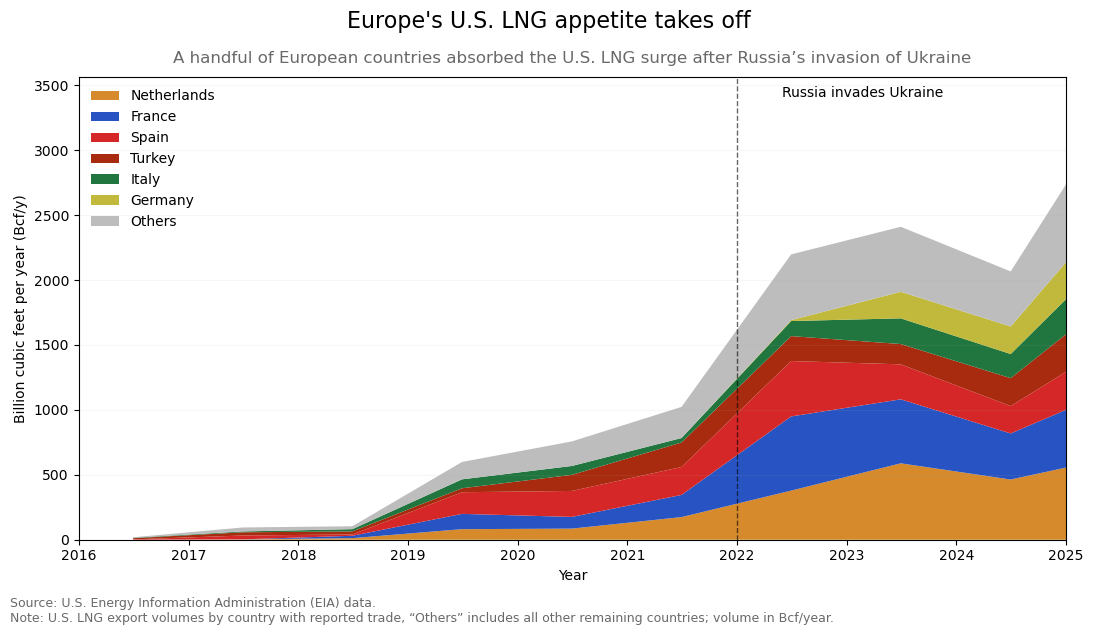

In [102]:
# MAP1: Which European nations are importing U.S. LNG, and how has that changed over time?

eu_pivot = eu_pivot.rename(columns={
    "turkiye": "Turkey",
    "others": "Others",
    "netherlands": "Netherlands",
    "france": "France",
    "spain": "Spain",
    "italy": "Italy",
    "germany": "Germany"
})

# correct order
desired_order = ["Netherlands", "France", "Spain", "Turkey", "Italy", "Germany", "Others"]
existing_order = [c for c in desired_order if c in eu_pivot.columns]
eu_pivot = eu_pivot[existing_order]

colors = [
    "#d68a2c",  # Netherlands
    "#2854c3",  # France
    "#d62728",  # Spain
    "#a92b0f",  # Turkey
    "#20763e",  # Italy
    "#c0b93c",  # Germany
    "#bdbdbd",  # Others
]

plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    eu_pivot.index,
    eu_pivot.T,
    labels=eu_pivot.columns,
    colors=colors
)

ax.axvline(
    x=pd.to_datetime("2022-01-01"),
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.annotate(
    "Russia invades Ukraine",
    xy=(pd.to_datetime("2022-01-01"), ax.get_ylim()[1]),
    xytext=(pd.to_datetime("2022-06-01"), ax.get_ylim()[1] * 0.95),
    fontsize=10,
    ha="left",
    va="bottom"
)

# HEADLINE
plt.suptitle(
    "Europe's U.S. LNG appetite takes off",
    fontsize=16
)

# DEK
ax.set_title(
    "A handful of European countries absorbed the U.S. LNG surge after Russia’s invasion of Ukraine",
    fontsize=12,
    color="dimgray",
    pad=10
)

ax.set_xlabel("Year")
ax.set_ylabel("Billion cubic feet per year (Bcf/y)")

ax.grid(True, axis="y", alpha=0.1)
ax.grid(False, axis="x")

ax.legend(loc="upper left", frameon=False)

ax.set_xlim(pd.to_datetime("2016-01-01"), pd.to_datetime("2025-01-01"))
ax.margins(x=0)

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# FOOTER
fig.text(
    0.01,
    -0.04,
    "Source: U.S. Energy Information Administration (EIA) data.\n"
    "Note: U.S. LNG export volumes by country with reported trade, “Others” includes all other remaining countries; volume in Bcf/year.",
    ha="left",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.savefig("lng_europe.svg", format="svg", bbox_inches="tight")
plt.show()

In [81]:
# assumes df.columns have already been cleaned to lowercase
vessel_cols = [
    col for col in df.columns
    if "by vessel to" in col or "by vessels to" in col
]

print(f"Found {len(vessel_cols)} vessel destination columns")

def extract_country(col):
    """
    Extract country name from columns like:
    'u.s. liquefied natural gas exports by vessel to france (million cubic feet)'
    """
    match = re.search(r"to (.+?) \(", col)
    return match.group(1).strip() if match else None

rename_map = {col: extract_country(col) for col in vessel_cols if extract_country(col) is not None}

# wide df with date + all  columns
lng_df = df[["date"] + vessel_cols].copy()

# convert values to numeric and from MMcf / million cubic feet to Bcf
for col in vessel_cols:
    lng_df[col] = pd.to_numeric(lng_df[col], errors="coerce") / 1000

# relabel to country names
lng_df = lng_df.rename(columns=rename_map)

# reshape to long format
lng_long = lng_df.melt(
    id_vars="date",
    var_name="country",
    value_name="lng_bcf"
)

# clean fields
lng_long["date"] = pd.to_datetime(lng_long["date"], errors="coerce")
lng_long["country"] = lng_long["country"].str.strip().str.lower()

# keep only useful rows
lng_long = lng_long.dropna(subset=["date", "lng_bcf"]).copy()
lng_long = lng_long[lng_long["date"] >= "2016-01-01"].copy()

print(lng_long.head())
print(lng_long["country"].nunique())
print(sorted(lng_long["country"].unique()))

Found 50 vessel destination columns
         date              country  lng_bcf
47 2020-06-30  antigua and barbuda    0.000
48 2021-06-30  antigua and barbuda    0.008
49 2022-06-30  antigua and barbuda    0.022
50 2023-06-30  antigua and barbuda    0.047
51 2024-06-30  antigua and barbuda    0.071
50
['antigua and barbuda', 'argentina', 'bahamas', 'bahrain', 'bangladesh', 'barbados', 'belgium', 'brazil', 'chile', 'china', 'colombia', 'croatia', 'dominican republic', 'egypt', 'el salvador', 'finland', 'france', 'germany', 'greece', 'haiti', 'india', 'indonesia', 'israel', 'italy', 'jamaica', 'japan', 'jordan', 'kuwait', 'lithuania', 'malaysia', 'malta', 'mauritania', 'mexico', 'netherlands', 'nicaragua', 'pakistan', 'panama', 'philippines', 'poland', 'portugal', 'russia', 'senegal', 'singapore', 'south korea', 'spain', 'taiwan', 'thailand', 'turkiye', 'united arab emirates', 'united kingdom']


In [82]:
#region maps
region_map = {
    # Europe
    "belgium": "Europe",
    "croatia": "Europe",
    "finland": "Europe",
    "france": "Europe",
    "germany": "Europe",
    "greece": "Europe",
    "italy": "Europe",
    "lithuania": "Europe",
    "malta": "Europe",
    "netherlands": "Europe",
    "poland": "Europe",
    "portugal": "Europe",
    "spain": "Europe",
    "turkiye": "Europe",
    "united kingdom": "Europe",

    # Asia 
    "bangladesh": "Asia",
    "china": "Asia",
    "india": "Asia",
    "indonesia": "Asia",
    "japan": "Asia",
    "malaysia": "Asia",
    "pakistan": "Asia",
    "philippines": "Asia",
    "singapore": "Asia",
    "south korea": "Asia",
    "taiwan": "Asia",
    "thailand": "Asia",

    # Latin America + Caribbean
    "antigua and barbuda": "Latin America & Caribbean",
    "argentina": "Latin America & Caribbean",
    "bahamas": "Latin America & Caribbean",
    "barbados": "Latin America & Caribbean",
    "brazil": "Latin America & Caribbean",
    "chile": "Latin America & Caribbean",
    "colombia": "Latin America & Caribbean",
    "dominican republic": "Latin America & Caribbean",
    "el salvador": "Latin America & Caribbean",
    "haiti": "Latin America & Caribbean",
    "jamaica": "Latin America & Caribbean",
    "mexico": "Latin America & Caribbean",
    "nicaragua": "Latin America & Caribbean",
    "panama": "Latin America & Caribbean",

    # Africa / other
    "israel": "Rest of World",
    "jordan": "Rest of World",
    "kuwait": "Rest of World",
    "bahrain": "Rest of World",
    "united arab emirates": "Rest of World",
    "egypt": "Rest of World",
    "mauritania": "Rest of World",
    "senegal": "Rest of World",
    "russia": "Rest of World",
}

country_region_df = pd.DataFrame({
    "column_name": list(country_map.keys()),
    "country": list(country_map.values())
})

country_region_df["region"] = country_region_df["country"].map(region_map)

# flag anything unmapped
unmapped = country_region_df[country_region_df["region"].isna()].copy()

print("\nCountry-region mapping:")
print(country_region_df.sort_values(["region", "country"]))

if not unmapped.empty:
    print("\nUnmapped countries found:")
    print(unmapped[["country", "column_name"]])
else:
    print("\nAll countries successfully mapped.")

column_to_region = dict(zip(country_region_df["column_name"], country_region_df["region"]))
column_to_country = dict(zip(country_region_df["column_name"], country_region_df["country"]))

NameError: name 'country_map' is not defined

In [83]:
#generate map with shares
map3 = lng_long.copy()
map3["country"] = map3["country"].str.strip().str.lower()
map3["region"] = map3["country"].map(region_map).fillna("Rest of World")

# aggregate by date and region
region_year = (
    map3.groupby(["date", "region"], as_index=False)["lng_bcf"]
    .sum()
)

# pivot wide
region_pivot = region_year.pivot(
    index="date",
    columns="region",
    values="lng_bcf"
).fillna(0)

# order columns
desired_order = ["Europe", "Asia", "Latin America & Caribbean", "Rest of World"]
existing_order = [c for c in desired_order if c in region_pivot.columns]
region_pivot = region_pivot[existing_order]

# convert to shares
region_share = region_pivot.div(region_pivot.sum(axis=1), axis=0) * 100

region_share 

region,Europe,Asia,Latin America & Caribbean,Rest of World
date,,,,
2016-06-30,10.181051,30.151030,46.650641,13.017278
2017-06-30,13.836516,45.698008,29.611217,10.854258
2018-06-30,14.325278,51.660350,28.265065,5.749307
2019-06-30,39.455138,36.786879,20.281370,3.476613
2020-06-30,38.445690,46.754765,12.699519,2.100025
2021-06-30,34.225655,47.186904,17.368654,1.218787
2022-06-30,68.903063,23.269869,6.351452,1.475616
2023-06-30,65.880117,26.430018,6.804006,0.885859
2024-06-30,53.024770,33.157604,9.165175,4.652451


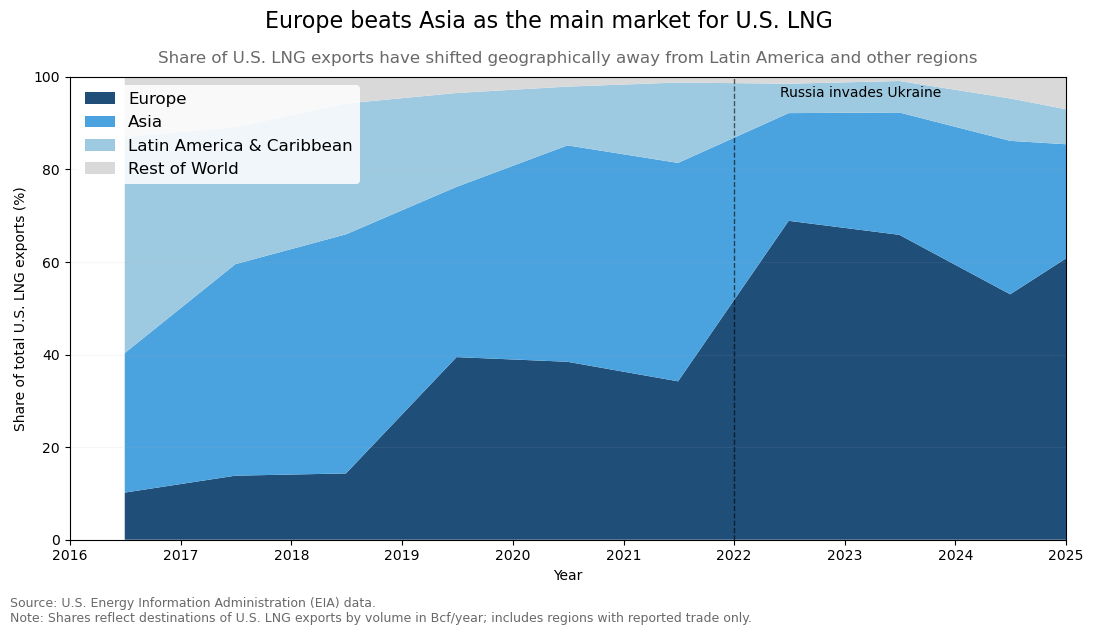

In [108]:
# MAP3: How did Europe fare compared to other nations?

fig, ax = plt.subplots(figsize=(11, 6))

plt.rcParams["font.family"] = "DejaVu Sans"

colors = [
    "#1f4e79",  # Europe
    "#4aa3df",  # Asia
    "#9ecae1",  # Latin America
    "#d9d9d9",  # Rest of world
]

ax.stackplot(
    region_share.index,
    region_share.T,
    labels=region_share.columns,
    colors=colors
)

# Ukraine marker
ax.axvline(
    x=pd.to_datetime("2022-01-01"),
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.annotate(
    "Russia invades Ukraine",
    xy=(pd.to_datetime("2022-01-01"), 100),
    xytext=(pd.to_datetime("2022-06-01"), 95),
    fontsize=10,
    ha="left",
    va="bottom"
)

# headline
plt.suptitle(
    "Europe beats Asia as the main market for U.S. LNG",
    fontsize=16
    )

# dek
ax.set_title(
    "Share of U.S. LNG exports have shifted geographically away from Latin America and other regions",
    fontsize=12,
    color="dimgray",
    pad=10
)

ax.set_xlabel("Year")
ax.set_ylabel("Share of total U.S. LNG exports (%)")
ax.set_ylim(0, 100)

ax.grid(True, axis="y", alpha=0.1)
ax.grid(False, axis="x")

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.85,
    fontsize=12,
    labelspacing=0.5,
    handlelength=1.8
)

ax.set_xlim(pd.to_datetime("2016-01-01"), pd.to_datetime("2025-01-01"))
ax.margins(x=0)

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# FOOTER
fig.text(
    0.01,
    -0.04,
    "Source: U.S. Energy Information Administration (EIA) data.\n"
    "Note: Shares reflect destinations of U.S. LNG exports by volume in Bcf/year; includes regions with reported trade only.",
    ha="left",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.savefig("lng_shares.svg", format="svg", bbox_inches="tight")
plt.show()

In [ ]:
file_path = "eu_energyproducts.xlsx"
df_eurostat = pd.read_excel(file_path)

df_eurostat.columns = df_eurostat.columns.str.strip().str.lower()
df_eurostat["energy product"] = df_eurostat["energy product"].str.strip().str.lower()
df_eurostat["country"] = df_eurostat["country"].str.strip()

# preview
print(df_eurostat.head())
print(df_eurostat.columns)

      date energy product country      share
0  Q1 2021            lng      US  24.084607
1  Q2 2021            lng      US  29.038321
2  Q3 2021            lng      US  27.814292
3  Q4 2021            lng      US  31.407482
4  Q1 2022            lng      US  48.628468
Index(['date', 'energy product', 'country', 'share'], dtype='object')


In [ ]:
df_eurostat["year"] = df_eurostat["date"].str[-4:].astype(int)
df_eurostat["quarter"] = df_eurostat["date"].str.extract(r"Q([1-4])").astype(int)

quarter_to_month = {1: 1, 2: 4, 3: 7, 4: 10}

df_eurostat["date_dt"] = pd.to_datetime({
    "year": df_eurostat["year"],
    "month": df_eurostat["quarter"].map(quarter_to_month),
    "day": 1
})

df_eurostat_pivot = df_eurostat.pivot_table(
    index=["energy product", "date_dt"],
    columns="country",
    values="share"
).sort_index()

df_plot = df_eurostat_pivot.reset_index()

print(df_plot.columns.tolist())
print(df_plot.head())

['energy product', 'date_dt', 'Algeria', 'Australia', 'Azerbaijan', 'Colombia', 'Kazakhstan', 'Lybia', 'Nigeria', 'Norway', 'Qatar', 'Russia', 'Saudi Arabia', 'UK', 'US']
country energy product    date_dt  Algeria  Australia  Azerbaijan   Colombia  \
0                 coal 2021-01-01      NaN  19.830623         NaN   7.548657   
1                 coal 2021-04-01      NaN  20.299955         NaN   4.352038   
2                 coal 2021-07-01      NaN  20.651672         NaN   8.037307   
3                 coal 2021-10-01      NaN  20.094344         NaN   9.306541   
4                 coal 2022-01-01      NaN  15.084122         NaN  12.449464   

country  Kazakhstan  Lybia  Nigeria  Norway  Qatar     Russia  Saudi Arabia  \
0          0.946228    NaN      NaN     NaN    NaN  45.497720           NaN   
1          0.564471    NaN      NaN     NaN    NaN  44.966426           NaN   
2          0.176411    NaN      NaN     NaN    NaN  46.543628           NaN   
3          0.444099    NaN      

In [ ]:
def plot_sparkline(ax, df, fuel, main_country="US", compare_country="Russia"):
    data = df[df["energy product"].str.lower() == fuel.lower()].copy()
    data = data.sort_values("date_dt")

    if compare_country in data.columns:
        ax.plot(data["date_dt"], data[compare_country],
                color="lightgray", linewidth=1.5)

    ax.plot(data["date_dt"], data[main_country],
            color="#1f4e79", linewidth=2.5)

    # endpoint label
    last_x = data["date_dt"].iloc[-1]
    last_y = data[main_country].iloc[-1]
    ax.text(last_x, last_y, f" {last_y:.0f}%", va="center", fontsize=9)

    # minimal axis context
    ax.set_title(fuel.title(), loc="left", fontsize=12)
    ax.set_xticks([data["date_dt"].min(), data["date_dt"].max()])
    ax.set_xticklabels([data["date_dt"].min().year, data["date_dt"].max().year], fontsize=8)
    ax.set_yticks([])

    # optional war marker
    ax.axvline(pd.to_datetime("2022-01-01"),
               color="gray", linestyle="--", linewidth=0.8, alpha=0.35)

    for spine in ax.spines.values():
        spine.set_visible(False)

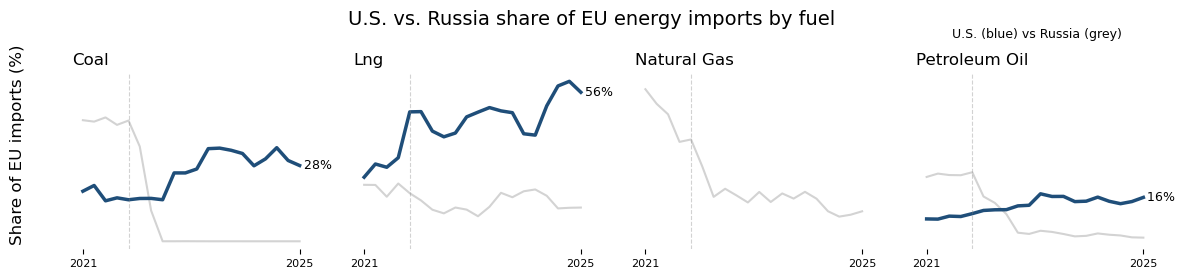

In [ ]:
import matplotlib.pyplot as plt

fuels = df_plot["energy product"].unique()

fig, axes = plt.subplots(1, len(fuels), figsize=(12, 2.8), sharey=True)

if len(fuels) == 1:
    axes = [axes]

for ax, fuel in zip(axes, fuels):
    plot_sparkline(ax, df_plot, fuel, main_country="US", compare_country="Russia")

fig.text(0.015, 0.5, "Share of EU imports (%)", va="center", rotation="vertical", fontsize=12)
fig.text(0.80, 0.88, "U.S. (blue) vs Russia (grey)", fontsize=9)

plt.suptitle("U.S. vs. Russia share of EU energy imports by fuel", fontsize=14)

plt.tight_layout(rect=[0.05, 0, 1, 1])

plt.show()

In [ ]:
fuels = df_plot["energy product"].unique()

fig, axes = plt.subplots(1, len(fuels), figsize=(12, 2.5))

for ax, fuel in zip(axes, fuels):
    plot_sparkline(ax, df_plot, fuel)

plt.suptitle("U.S. share of EU energy imports by fuel", fontsize=14)
plt.tight_layout()
plt.show()